# Датасет для сегментации зубов
**Название**: teeth-seg-3537 Computer Vision Model      
**Автор**: Godento2 ([Roboflow](https://universe.roboflow.com/godento2/teeth-seg-3537-iaky1))     
**Количество снимков**: в оригинале более 3500 снимков, однако присутствуют детские снимки. После очистки - более 2300 снимков: train / val / test = 1730 / 397 /259     
**Размер изображений**: 640x640    
**Лицензия**: CC BY 4.0



# Анализ датасета

## Установка пакетов, импорт библиотек

In [1]:
# Установка tree
!apt-get install tree -qqq > /dev/null

In [2]:
import os
from google.colab import drive
import numpy as np
import pandas as pd
import cv2
from tqdm.notebook import tqdm
import zipfile
import random
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
# настройка визуализации
%matplotlib inline
plt.style.use('seaborn-v0_8')
%config InlineBackend.figure_format = "retina"

## Функции для визуализации примеров

In [3]:
def generate_class_colors(num_classes: int = 32) -> Dict[int, Tuple[int, int, int]]:
    """
    Функция генерирует цвета для классов.

    Цвета равномерно распределяются по оттенку в пространстве HSV (OpenCV-диапазоны:
    H∈[0,179], S∈[0,255], V∈[0,255]) и затем конвертируются в RGB. Это даёт
    устойчивую, воспроизводимую палитру без случайности.

    Args:
        num_classes: Число классов (по умолчанию 32 по числу зубов).

    Returns:
        Словарь {id_класса: (R, G, B)} с целочисленными значениями 0..255.
    """
    colors: Dict[int, Tuple[int, int, int]] = {}
    for cls in range(num_classes):
        # Равномерное распределение оттенков по кругу
        hue = int(179 * cls / num_classes)   # H ∈ [0,179] в OpenCV
        saturation = 230                     # высокая насыщенность
        value = 230                          # высокая яркость
        color_hsv = np.uint8([[[hue, saturation, value]]])
        # Конвертация HSV -> RGB (получаем (R,G,B))
        color_rgb = cv2.cvtColor(color_hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors[cls] = (int(color_rgb[0]), int(color_rgb[1]), int(color_rgb[2]))
    return colors

def load_yolo_segmentation(label_path: str, img_w: int, img_h: int) -> List[Tuple[int, np.ndarray]]:
    """
    Функция для загрузки разметки YOLO для задачи сегментации.

    Формат строки в .txt для сегментации:
        class_id x1 y1 x2 y2 ... xN yN
    где координаты нормированы в [0,1] относительно ширины/высоты изображения.

    Args:
        label_path: Путь к .txt-файлу разметки.
        img_w: Ширина изображения (в пикселях).
        img_h: Высота изображения (в пикселях).

    Returns:
        Список кортежей (class_id, poly), где poly — np.ndarray формы (N,2) с
        координатами вершин полигона в пикселях (dtype=int32).
        Если файла нет или он пуст, возвращает пустой список.
    """
    polygons: List[Tuple[int, np.ndarray]] = []
    if not os.path.exists(label_path):
        return polygons

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            # Минимум: class + 3 точки (6 чисел) => 1 + 6 = 7 токенов
            if len(parts) < 7:
                continue
            cls = int(float(parts[0]))
            coords = list(map(float, parts[1:]))

            # Координаты должны идти парами (x,y)
            if len(coords) % 2 != 0:
                # Нечётное число координат — пропускаем строку
                continue

            # Денормализация из [0,1] в пиксели
            poly_pts = []
            for i in range(0, len(coords), 2):
                x = int(round(coords[i] * img_w))
                y = int(round(coords[i+1] * img_h))
                # Подстраховка от выхода за границы
                x = np.clip(x, 0, img_w - 1)
                y = np.clip(y, 0, img_h - 1)
                poly_pts.append((x, y))

            if len(poly_pts) >= 3:  # полигон минимум из 3 точек
                polygons.append((cls, np.array(poly_pts, dtype=np.int32)))
    return polygons

def show_random_segmented_images(
    subset: str = 'train',
    num_images: int = 3,
    dataset_path: str = '/content/dataset'
) -> None:
    """
    Визуализирует N случайных изображений из указанной подвыборки и сегментирует их.

    Функция:
      1) выбирает случайно `num_images` файлов из {dataset_path}/{subset}/images;
      2) для каждого изображения ищет соответствующий .txt-файл в labels;
      3) считывает полигональные маски (YOLO segmentation !!!), денормализует координаты;
      4) отрисовывает поверх изображения полупрозрачные маски и контуры;
      5) показывает два кадра рядом: оригинал и изображение с разметкой.

    Примечания:
    - Цвет каждого класса фиксирован и определяется словарём `CLASS_COLORS` из 32 цветов.
    - Если для изображения нет .txt или разметка пуста/некорректна, будет показан только фон без масок.
    - Изображение конвертируется в RGB (OpenCV читает в BGR), поэтому цвета отображаются корректно в matplotlib.

    Args:
        subset: Название подвыборки ('train', 'valid' или 'test').
        num_images: Сколько случайных изображений отобразить (автоматически ограничивается размером набора).
        dataset_path: Корневая папка датасета.

    Returns:
        None. Функция выводит графики через matplotlib.

    Raises:
        FileNotFoundError: Если не найдена папка с изображениями {dataset_path}/{subset}/images.
        ValueError: Если в подвыборке нет ни одного изображения.
    """
    # Пути к папкам изображений и разметок
    images_dir = os.path.join(dataset_path, subset, 'images')
    labels_dir = os.path.join(dataset_path, subset, 'labels')

    if not os.path.isdir(images_dir):
        raise FileNotFoundError(
            f"Не найдена папка с изображениями: {images_dir}. "
            f"Проверьте аргументы dataset_path/subset и структуру датасета."
        )

    # Список поддерживаемых графических форматов
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(exts)]

    if len(image_files) == 0:
        raise ValueError(f"В подвыборке '{subset}' не найдено ни одного изображения в {images_dir}.")

    # Случайная выборка без повторений
    k = min(num_images, len(image_files))
    sample_files = random.sample(image_files, k)

    for img_name in sample_files:
        img_path = os.path.join(images_dir, img_name)
        # Разметка с тем же именем, но расширение .txt
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')

        # Чтение изображения (BGR) и конвертация в RGB для корректного отображения в matplotlib
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            # Если по какой-то причине файл не читается, пропускаем его
            print(f"[WARN] Не удалось прочитать изображение: {img_path}")
            continue
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]

        # Загрузка полигонов сегментации из YOLO-текста
        polygons = load_yolo_segmentation(label_path, img_w, img_h)

        # Подложка для отрисовки масок и контуров
        overlay = img.copy()

        # Рисуем все полигоны: сначала контуры, затем заливку
        for cls, poly in polygons:
            color = CLASS_COLORS.get(cls, (255, 255, 255))  # на всякий случай, если класс вне диапазона
            # Контур полигона
            cv2.polylines(overlay, [poly], isClosed=True, color=color, thickness=2)
            # Заливка полигона
            cv2.fillPoly(overlay, [poly], color)

        # Полупрозрачное наложение масок на исходник
        alpha = 0.4  # степень прозрачности маски (0..1)
        img_with_mask = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

        # Визуализация: оригинал и с разметкой рядом
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        axes[0].imshow(img)
        axes[0].set_title("Оригинальное изображение")
        axes[0].axis('off')

        axes[1].imshow(img_with_mask)
        axes[1].set_title("С YOLO сегментацией (фиксированные цвета)")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

## Установка параметров

In [4]:
DATASET_PATH_ZIP = '/content/gdrive/MyDrive/Colab_Notebooks/Startup/02_Datasets/Godento2v2.zip'
DATASET_PATH_UNZIP = '/content'
DATASET_DIR = '/content/dataset'

## Получение датасета

In [5]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
# Распаковываем
with zipfile.ZipFile(DATASET_PATH_ZIP, 'r') as zip_ref:
    for file in tqdm(zip_ref.namelist(), desc='Распаковка архива'):
        zip_ref.extract(file, DATASET_PATH_UNZIP)

# переименовываем каталог с распакованным датасетом
os.rename('/content/Godento2v2', '/content/dataset')

print(f"\nАрхив успешно распакован в: {DATASET_DIR}")

Распаковка архива:   0%|          | 0/11560 [00:00<?, ?it/s]


Архив успешно распакован в: /content/dataset


## Анализ датасета

In [7]:
!tree /content/dataset// -L 3 -d  # -d только директории, -L 3 - глубина 3 уровня

/content/dataset//
├── test
│   ├── images
│   └── labels
├── train
│   ├── images
│   └── labels
└── valid
    ├── images
    └── labels

9 directories


Подвыборка  Количество изображений  Процент
     train                    1730     72.5
     valid                     397     16.6
      test                     259     10.9


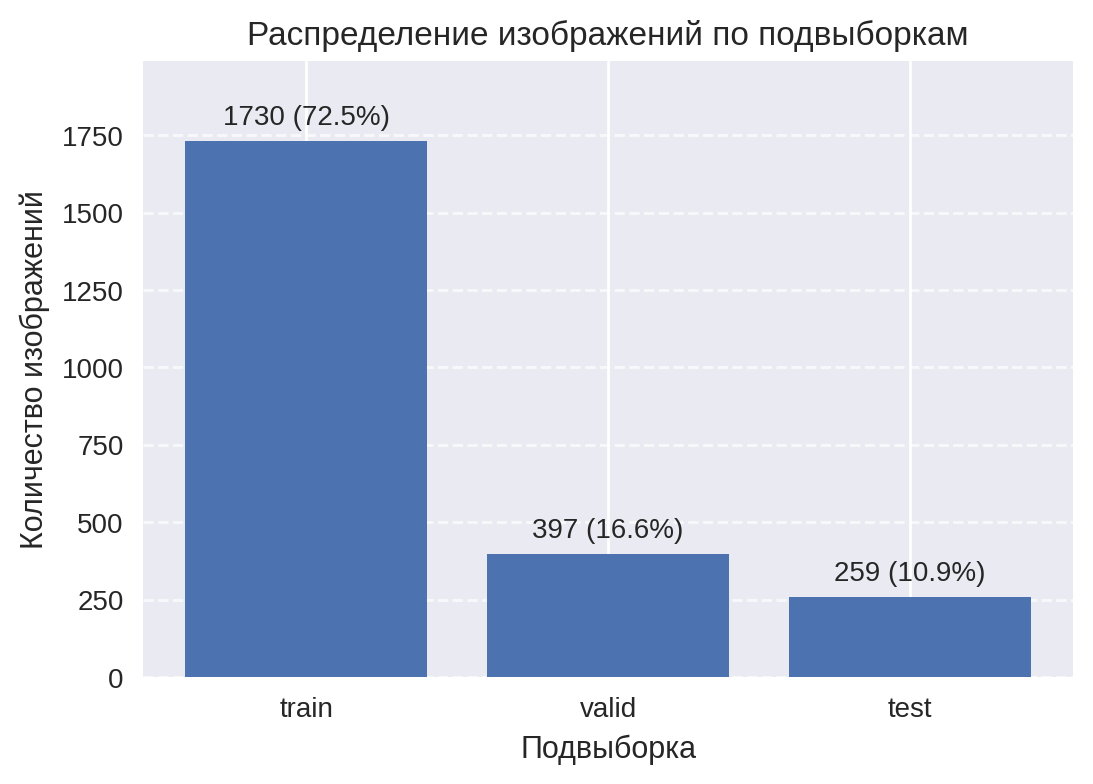

In [8]:
## Количество изображений в подвыборках датасета

# список подвыборок
splits = ['train', 'valid', 'test']

## Расчет количества изображений в каждой подвыборке
data = []
for split in splits:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    if os.path.exists(img_dir):
        num_images = sum(1 for f in os.listdir(img_dir) if os.path.isfile(os.path.join(img_dir, f)))
    else:
        num_images = 0
    data.append({'Подвыборка': split, 'Количество изображений': num_images})

# Переводим собранные данные в датафрейм
df = pd.DataFrame(data)

# Добавляем колонку с процентами
total = df['Количество изображений'].sum()
df['Процент'] = (df['Количество изображений'] / total * 100).round(1)

# Вывод таблицы
print(df.to_string(index=False))

# Диаграмма с подписями
plt.figure(figsize=(6, 4))
bars = plt.bar(df['Подвыборка'], df['Количество изображений'])
plt.xlabel('Подвыборка')
plt.ylabel('Количество изображений')
plt.title('Распределение изображений по подвыборкам')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Запас сверху
max_val = df['Количество изображений'].max()
plt.ylim(0, max_val * 1.15)

# Подписи: количество + процент
for bar, perc in zip(bars, df['Процент']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height + max_val * 0.02,
             f"{height} ({perc}%)",
             ha='center', va='bottom', fontsize=10)

plt.show()

## Пример изображений

In [9]:
# генерируем цвета для масок по числу зубов
CLASS_COLORS = generate_class_colors(32)

In [11]:
# 3 случайных изображения из train
show_random_segmented_images(subset='train', num_images=3, dataset_path=DATASET_DIR)

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# 3 случайных изображения из valid
show_random_segmented_images(subset='valid', num_images=3, dataset_path=DATASET_DIR)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
# 3 случайных изображения из test
show_random_segmented_images(subset='test', num_images=3, dataset_path=DATASET_DIR)

Output hidden; open in https://colab.research.google.com to view.

# Выводы:
- плюсы датасета:
  - большое число снимков, даже после очистки от детских ортопантомограмм
  - нет дефектов разметки, размечен каждый зуб
  - на ОПТГ имеются артефакты: металлические конструкции, пломбы и пр.
  - имеются различные формы и количество зубов
  - качество снимков относительно неплохое
  - лицензия позволяет его использование в коммерческих целях
- минусы датасета:
  - разметка не очень точная, границы зубов прорисованы нечетко, что может сбивать модель при обучении
- особенности датасета:
  - изображения сразу обработаны для подачи в модель: размер 640x640